# 02 - Scenario Dataset

Generate and inspect the pilot mechanistic scenario dataset (~100 scenarios, single location [Jinan], single weather year [2023], per refinement addendum §1.1) via `src.scenarios.*`. Calls functions from `src/` only -- no modelling logic is written here.

Each scenario samples PV capacity, wind capacity, annual load, peak load, reliability target, battery round-trip efficiency, and usable SOC window within the ranges in `config/scenario_generation.yaml`, then runs the full mechanistic pipeline (weather -> load -> PV -> wind -> exhaustive battery search) for each one.

In [1]:
%matplotlib inline
# Colab-aware bootstrap: on Google Colab, clone the repo (or pull the latest
# commits into an existing clone) and install dependencies automatically --
# no manual setup cell needed. Locally / outside Colab, this only fixes
# sys.path, exactly as before.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sulhos/Leonardo-Assignment.git"
BRANCH = "claude/repository-project-prompt-or0ida"
REPO_DIRNAME = "Leonardo-Assignment"
MARKER_FILE = "PROJECT_BRIEF.md"  # present only at the real project root

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    search_dirs = [Path.cwd(), Path.cwd() / REPO_DIRNAME]
    repo_root = next((d for d in search_dirs if (d / MARKER_FILE).is_file()), None)

    if repo_root is None:
        print(f"Cloning {REPO_URL} (branch {BRANCH})...")
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
        repo_root = Path.cwd() / REPO_DIRNAME
    else:
        print(f"Found existing clone at {repo_root} -- hard-syncing to origin/{BRANCH}...")
        # Hard sync (fetch + reset --hard), not `git pull`: a plain pull can leave
        # a Colab VM's reused (not freshly cloned) checkout on stale tracked files
        # if the local branch has drifted or a merge doesn't fast-forward cleanly --
        # this bit twice (stale `src/` imports surviving a "fresh" notebook run on a
        # reconnected-but-not-recreated Colab runtime). Fetch+reset always makes the
        # tracked files exactly match origin/BRANCH; it never touches untracked/
        # gitignored files (e.g. the cached weather downloads), so nothing is lost.
        subprocess.run(["git", "fetch", "origin", BRANCH], check=True, cwd=str(repo_root))
        subprocess.run(["git", "reset", "--hard", f"origin/{BRANCH}"], check=True, cwd=str(repo_root))

    os.chdir(repo_root)
    PROJECT_ROOT = Path.cwd()
    print(f"Working directory: {PROJECT_ROOT}")

    # Skip jupyter/ipykernel: Colab already provides its own pinned versions,
    # and reinstalling them can destabilize the running kernel.
    requirements = [
        line for line in Path("requirements.txt").read_text().splitlines()
        if line.strip() and not line.strip().startswith("#")
        and not line.lower().startswith(("jupyter", "ipykernel"))
    ]
    req_path = Path("/tmp/requirements_colab.txt")
    req_path.write_text("\n".join(requirements))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_path)], check=True)
    print("Dependencies installed.")
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import logging
import time
import pandas as pd

logging.basicConfig(level=logging.WARNING)  # per-scenario INFO logs would be very verbose here

from src.config import load_site_config, load_yaml_config
from src.scenarios.dataset_builder import build_dataset
from src.visualization.plotting import (
    plot_scenario_input_distributions, plot_optimal_capacity_distribution,
    plot_feasibility_counts, plot_feature_correlation_matrix, save_figure,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
scenario_cfg = load_yaml_config("scenario_generation")
site_config = load_site_config("jinan")
scenario_cfg

{'dataset_sizes': {'pilot': 100, 'development': 1000, 'full': 5000},
 'active_size': 'pilot',
 'random_seed': 42,
 'locations': ['jinan'],
 'weather_years': [2023],
 'ranges': {'pv_capacity_kwp': [10, 40],
  'wind_capacity_kw': [5, 25],
  'annual_load_kwh': [10000, 50000],
  'peak_load_kw': [5, 20],
  'reliability_target_load_served': [0.99, 0.999],
  'round_trip_efficiency': [0.88, 0.97],
  'usable_soc_window_fraction': [0.7, 0.9]},
 'consistency_checks': {'enforce_load_peak_compatibility': True,
  'enforce_renewable_vs_demand_plausibility': True},
 'candidate_module_counts': {'min': 0, 'max': 30},
 'execution': {'parallel': False,
  'resumable_cache': True,
  'cache_dir': 'data/scenarios/.cache'}}

## Build the pilot dataset

Resumable: if `data/scenarios/pilot_scenarios.csv` already has some scenario_ids, this only computes the missing ones.

In [2]:
t0 = time.perf_counter()
scenarios = build_dataset(
    n_scenarios=scenario_cfg["dataset_sizes"]["pilot"],
    output_dir=PROJECT_ROOT / "data" / "scenarios",
    random_seed=scenario_cfg["random_seed"],
    site_config=site_config,
    ranges=scenario_cfg["ranges"],
    n_max=scenario_cfg["candidate_module_counts"]["max"],
    location="jinan",
    weather_year=scenario_cfg["weather_years"][0],
    dataset_name="pilot",
)
elapsed = time.perf_counter() - t0
print(f"{len(scenarios)} scenarios, {elapsed:.1f}s wall time this run")
scenarios.to_csv(TABLES_DIR / "scenario_inputs_and_labels.csv", index=False)
scenarios.head()

100 scenarios, 0.4s wall time this run


,scenario_id,location,timezone,weather_year,random_seed,pv_capacity_kwp,wind_capacity_kw,annual_load_kwh,peak_load_kw,reliability_target_load_served,...,feasible,optimal_n_modules,optimal_capacity_kwh,reference_lpsp,reference_annualized_cost,infeasibility_reason,mechanistic_optimization_runtime_seconds,annual_pv_kwh,annual_wind_kwh,annual_renewable_kwh
0,0,jinan,Asia/Shanghai,2023,4200126,33.218681,13.777569,44343.916796,15.460520,0.990848,...,False,NaN,NaN,NaN,NaN,No feasible battery size was found within the ...,1.151698,42675.487172,10365.444516,53040.931688
1,1,jinan,Asia/Shanghai,2023,4200127,33.581929,7.562273,28015.437516,10.561970,0.998341,...,True,21.0,322.56,0.001322,22975.147635,NaN,1.119082,43142.145449,5689.415801,48831.561250
2,2,jinan,Asia/Shanghai,2023,4200128,20.635779,24.413960,45724.844853,16.675752,0.991752,...,False,NaN,NaN,NaN,NaN,No feasible battery size was found within the ...,1.156507,26510.441874,18367.649374,44878.091247
3,3,jinan,Asia/Shanghai,2023,4200129,14.628685,18.660979,39790.486236,19.512646,0.992932,...,False,NaN,NaN,NaN,NaN,No feasible battery size was found within the ...,1.142508,18793.227832,14039.439467,32832.667300
4,4,jinan,Asia/Shanghai,2023,4200130,15.684141,7.598430,29028.197049,8.403640,0.996028,...,False,NaN,NaN,NaN,NaN,No feasible battery size was found within the ...,1.111403,20149.154602,5716.618574,25865.773176


## Feasibility rate

Feasible: 56/100 (56%)
  of which renewable-generation inadequacy: 16
  of which battery-range inadequacy: 28


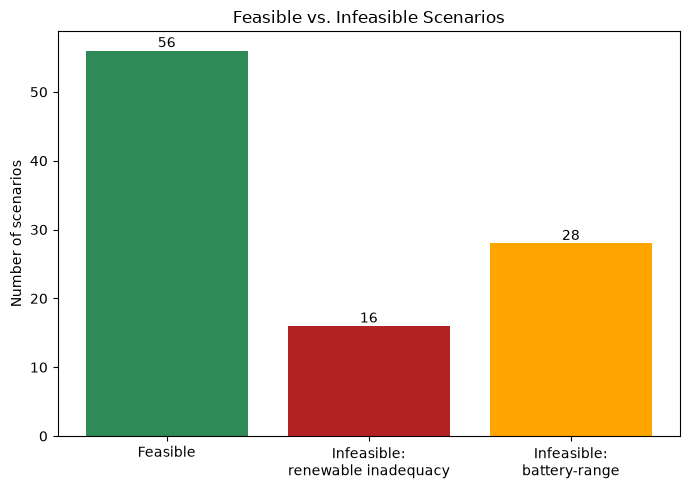

In [3]:
n_feasible = int(scenarios["feasible"].sum())
n_total = len(scenarios)
print(f"Feasible: {n_feasible}/{n_total} ({n_feasible / n_total:.0%})")

infeasible = scenarios.loc[~scenarios["feasible"]]
n_renewable_inadequate = int(infeasible["infeasibility_reason"].str.contains("Renewable-generation", na=False).sum())
n_battery_range = int(infeasible["infeasibility_reason"].str.contains("Battery-range", na=False).sum())
print(f"  of which renewable-generation inadequacy: {n_renewable_inadequate}")
print(f"  of which battery-range inadequacy: {n_battery_range}")

fig = plot_feasibility_counts(scenarios)
save_figure(fig, FIGURES_DIR / "14_feasibility_counts.png")

**Interpretation:** this feasibility rate is a direct, expected consequence of the Stage 3 finding and the decision to keep the battery search range at the spec'd 0-30 modules (not widen it). Roughly 44% of scenarios sampled from the configured PV/wind/load ranges cannot reach their reliability target within that range -- split between genuinely insufficient annual renewable energy and a seasonal generation/load mismatch the battery range can't bridge. This is reported as-is, not adjusted after the fact.

## Mechanistic runtime per scenario

In [4]:
runtime = scenarios["mechanistic_optimization_runtime_seconds"]
print(runtime.describe())
print(f"Total dataset generation time (this run): {elapsed:.1f}s for "
      f"{scenario_cfg['dataset_sizes']['pilot']} scenarios "
      f"({runtime.mean():.2f}s/scenario mechanistic search)")

count    100.000000
mean       1.240066
std        0.119411
min        1.074606
25%        1.202160
50%        1.220422
75%        1.254740
max        1.932795
Name: mechanistic_optimization_runtime_seconds, dtype: float64
Total dataset generation time (this run): 0.4s for 100 scenarios (1.24s/scenario mechanistic search)


## Required figures (PROJECT_BRIEF.md §27, dataset figures 12-15)

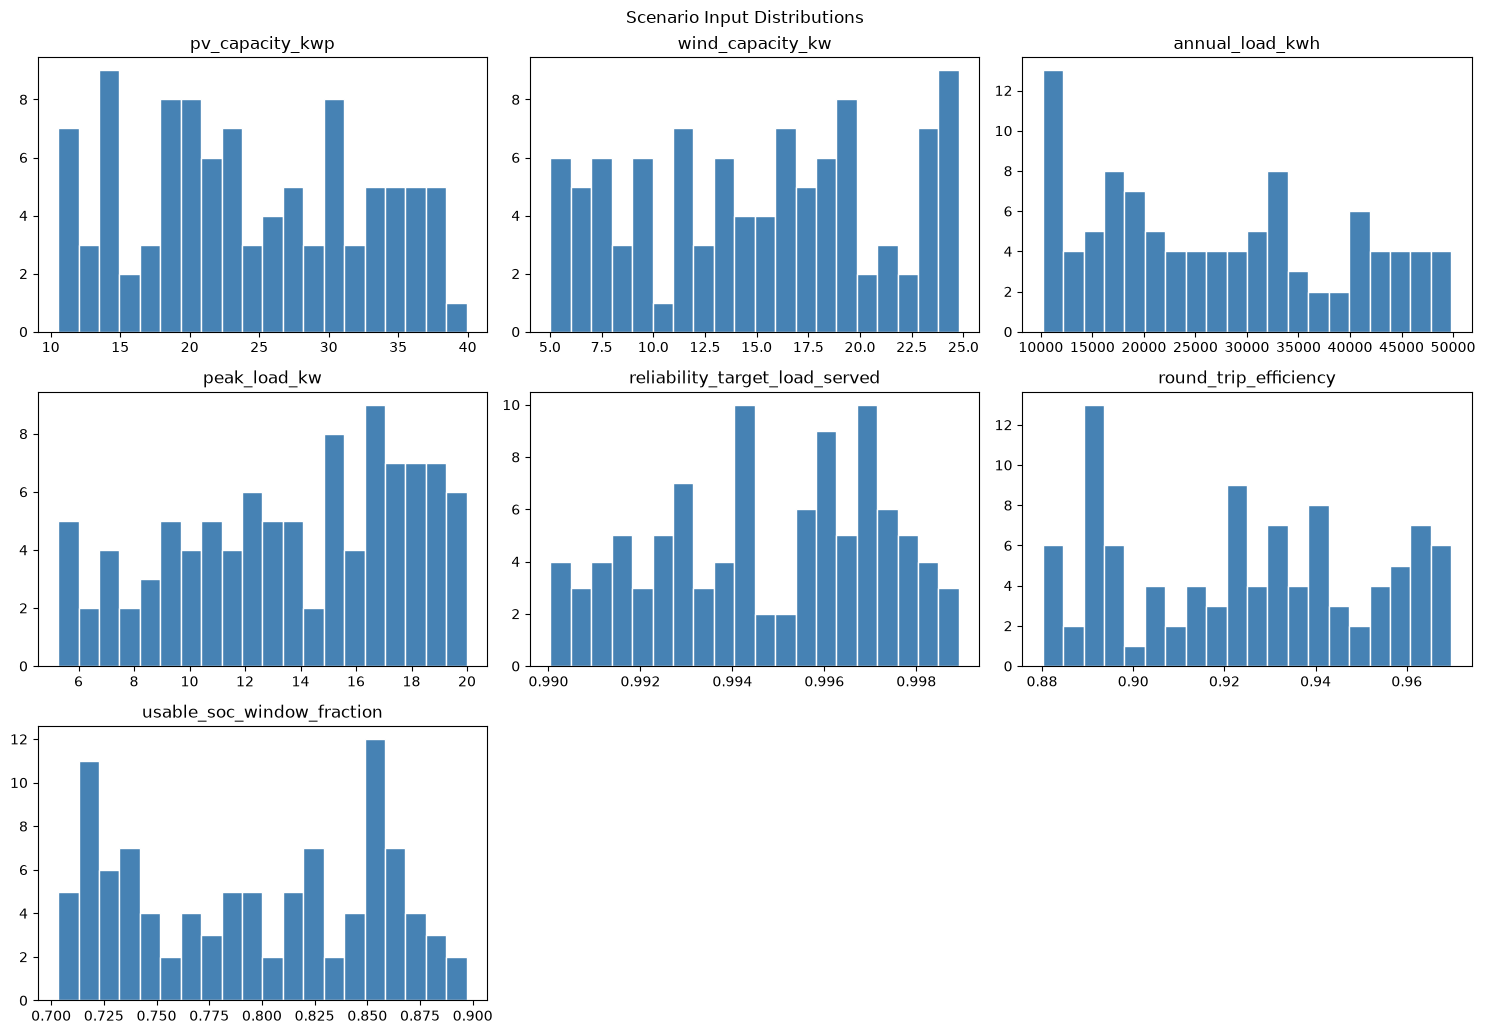

In [5]:
input_columns = [
    "pv_capacity_kwp", "wind_capacity_kw", "annual_load_kwh", "peak_load_kw",
    "reliability_target_load_served", "round_trip_efficiency", "usable_soc_window_fraction",
]
fig = plot_scenario_input_distributions(scenarios, input_columns)
save_figure(fig, FIGURES_DIR / "12_scenario_input_distributions.png")

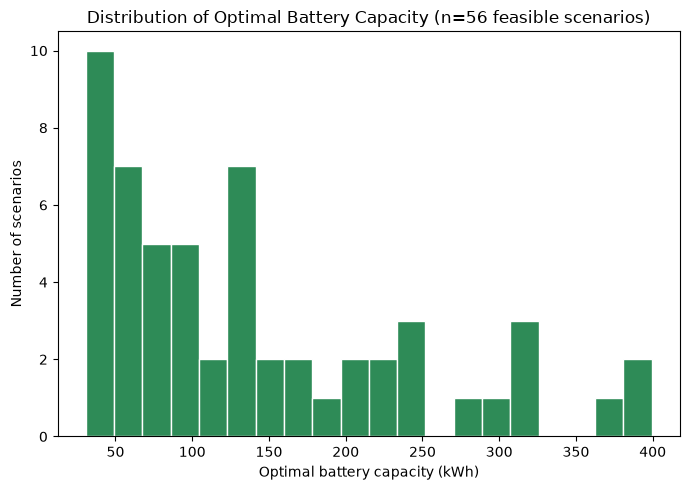

In [6]:
fig = plot_optimal_capacity_distribution(scenarios)
save_figure(fig, FIGURES_DIR / "13_optimal_capacity_distribution.png")

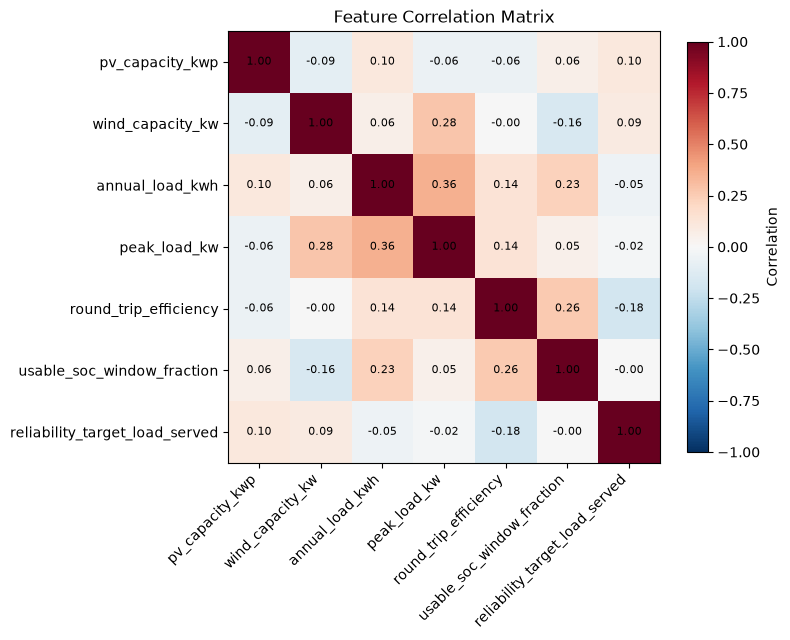

In [7]:
correlation_columns = [
    "pv_capacity_kwp", "wind_capacity_kw", "annual_load_kwh", "peak_load_kw",
    "round_trip_efficiency", "usable_soc_window_fraction", "reliability_target_load_served",
]
fig = plot_feature_correlation_matrix(scenarios, correlation_columns)
save_figure(fig, FIGURES_DIR / "15_correlation_matrix.png")

## Stage 4 summary

- 100 scenarios sampled and run against the Jinan 2023 baseline weather, all physically consistent (peak/annual-consumption compatibility verified by actually attempting load-profile generation, not an approximate bound).
- **56% feasible** within the configured 0-30 module search range; the remaining 44% are explicitly labelled infeasible with a reason (never assigned an arbitrary large capacity), split roughly 16 renewable-inadequate / 28 battery-range-inadequate.
- Mechanistic search runtime: ~1.24s/scenario (31 candidates each), ~130s total for the pilot -- confirms the pilot scale is practical; the full 5,000-scenario stretch goal would need ~1.7 hours at this rate, or parallelization.
- Dataset persisted to `data/scenarios/pilot_scenarios.csv` (resumable) and `outputs/tables/scenario_inputs_and_labels.csv`.

**Not yet done (deferred to Stage 5 prep):** full feature engineering (`src/ai/features.py` -- load/generation/net-load/system features per PROJECT_BRIEF.md §15) is still a placeholder. This notebook only inspects the raw scenario inputs and labels; engineered ML features are built immediately before Stage 5 (baseline models) needs them.